# Quantum Concrete Crack Classification

This notebook follows a similar staged workflow to the YOLO notebook, but uses a **hybrid Quantum CNN** for crack classification.

Pipeline: environment checks → data preparation → hybrid quantum model setup → training → evaluation → final summary.

## 1. Environment Setup
Use the dedicated environment created for this stage: `quantum_cnn/.venv`.

In [ ]:
import sys
import time
import random
from pathlib import Path

import numpy as np
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

print('Python:', sys.executable)
print('PyTorch:', torch.__version__)
print('NumPy:', np.__version__)

Python: /usr/local/bin/python3
PyTorch: 2.2.2
NumPy: 1.26.4


In [2]:
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)

if torch.cuda.is_available():
    device = 'cuda'
    print(f'GPU detected: {torch.cuda.get_device_name(0)}')
else:
    device = 'cpu'
    print('No GPU detected, using CPU.')

print('Device:', device)

No GPU detected, using CPU.
Device: cpu


## 2. Data Preparation

In [8]:
cwd = Path.cwd().resolve()

# Navigate up to project root (handles running from quantum_cnn/notebooks)
if (cwd / 'src').exists():
    PROJECT_ROOT = cwd
elif (cwd.parent / 'src').exists():
    PROJECT_ROOT = cwd.parent
elif (cwd.parent.parent / 'src').exists():
    PROJECT_ROOT = cwd.parent.parent
else:
    PROJECT_ROOT = cwd

SRC_PATH = PROJECT_ROOT / 'src'
if str(SRC_PATH) not in sys.path:
    sys.path.append(str(SRC_PATH))

# Dataset is in the project root
DATASET_ROOT = PROJECT_ROOT / 'raw_classification'

print('Project root:', PROJECT_ROOT)
print('Dataset root:', DATASET_ROOT)
print('Dataset exists:', DATASET_ROOT.exists())

Project root: /Users/anton/Documents/GitHub/Final_Year_Project
Dataset root: /Users/anton/Documents/GitHub/Final_Year_Project/raw_classification
Dataset exists: True


In [9]:
if not DATASET_ROOT.exists():
    raise FileNotFoundError(f'Dataset directory not found: {DATASET_ROOT}')

class_dirs = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
if len(class_dirs) < 2:
    raise RuntimeError('Expected at least two class folders under raw_classification/')

print('Detected classes:')
total_images = 0
for class_dir in class_dirs:
    count = len(list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.png')))
    total_images += count
    print(f'  - {class_dir.name}: {count}')

print(f'Total images: {total_images}')

Detected classes:
  - cracked: 20000
  - not_cracked: 20000
Total images: 40000
  - cracked: 20000
  - not_cracked: 20000
Total images: 40000


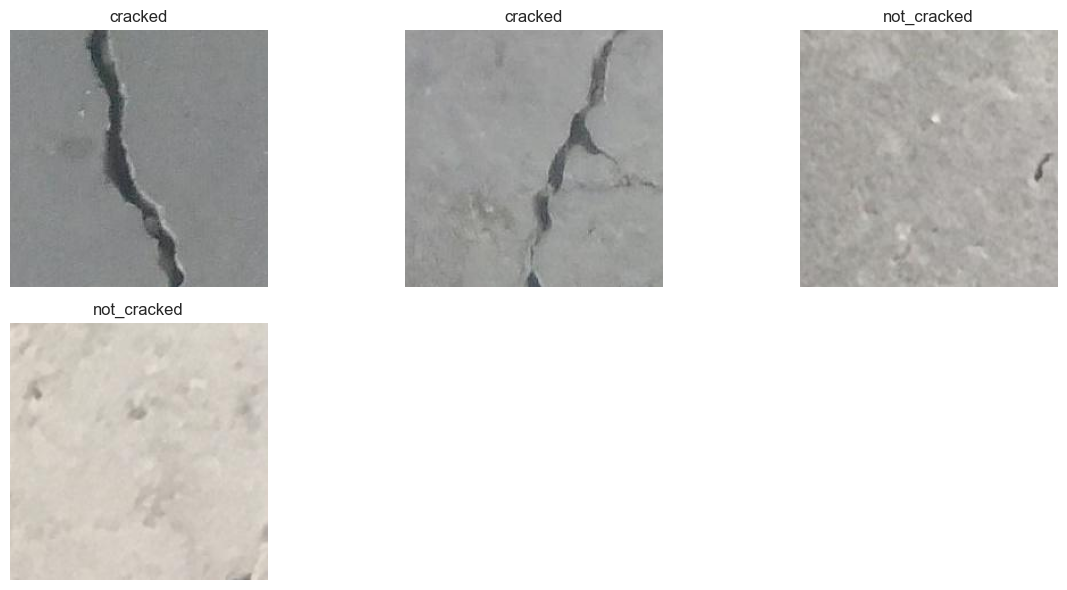

In [10]:
import cv2

sample_paths = []
for class_dir in class_dirs:
    candidates = sorted(list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.jpeg')) + list(class_dir.glob('*.png')))
    sample_paths.extend(candidates[:2])

show_n = min(6, len(sample_paths))
plt.figure(figsize=(12, 6))
for i, img_path in enumerate(sample_paths[:show_n], 1):
    img_bgr = cv2.imread(str(img_path))
    img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    plt.subplot(2, 3, i)
    plt.imshow(img_rgb)
    plt.title(img_path.parent.name)
    plt.axis('off')
plt.tight_layout()
plt.show()

## 3. Quantum CNN Configuration

In [33]:
from quantum_cnn.config import QuantumCNNConfig
import pandas as pd
from IPython.display import display
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

config = QuantumCNNConfig(
    dataset_root=str(DATASET_ROOT),
    image_size=32,
    batch_size=32,
    train_ratio=0.70,
    val_ratio=0.15,
    test_ratio=0.15,
    learning_rate=1e-3,
    weight_decay=1e-4,
    epochs=8,
    seed=RANDOM_SEED,
    n_qubits=4,
    n_q_layers=2,
    quantum_embedding_dim=8,
    hidden_dim=64,
    max_train_samples=7000,
    max_val_samples=1500,
    max_test_samples=1500,
    output_root=str(PROJECT_ROOT / 'runs' / 'quantum_cnn'),
    experiment_name='notebook_run',
)

# Create visual configuration table
config_data = {
    'Configuration Item': [
        'Model Type',
        'Image Size',
        'Batch Size',
        'Random Seed',
        '',
        'Training Configuration',
        'Training Samples',
        'Validation Samples',
        'Test Samples',
        'Train Ratio',
        'Val Ratio',
        'Test Ratio',
        'Epochs',
        'Learning Rate',
        'Weight Decay',
        '',
        'Quantum Architecture',
        'Number of Qubits',
        'Quantum Layers',
        'Quantum Embedding Dim',
        'Classical Hidden Dim',
        '',
        'Preprocessing',
        'Use Grayscale',
        'Use CLAHE',
        'Quantum Preprocess',
    ],
    'Value': [
        'Hybrid Quantum CNN',
        f'{config.image_size}x{config.image_size}px',
        str(config.batch_size),
        str(config.seed),
        '',
        '',
        f'{config.max_train_samples} (max)',
        f'{config.max_val_samples} (max)',
        f'{config.max_test_samples} (max)',
        f'{config.train_ratio:.0%}',
        f'{config.val_ratio:.0%}',
        f'{config.test_ratio:.0%}',
        str(config.epochs),
        f'{config.learning_rate:.0e}',
        f'{config.weight_decay:.0e}',
        '',
        '',
        str(config.n_qubits),
        str(config.n_q_layers),
        str(config.quantum_embedding_dim),
        str(config.hidden_dim),
        '',
        '',
        'Yes' if config.use_grayscale else 'No',
        'Yes' if config.use_clahe else 'No',
        'Yes' if config.quantum_preprocess else 'No',
    ],
    'Description': [
        'Classical CNN + 4-qubit quantum circuit',
        'Input image dimensions',
        'Samples per training batch',
        'For reproducibility',
        '',
        '',
        'Maximum training samples to use',
        'Maximum validation samples to use',
        'Maximum test samples to use',
        'Fraction of data for training',
        'Fraction of data for validation',
        'Fraction of data for testing',
        'Maximum training iterations',
        'Initial learning rate (AdamW)',
        'L2 regularization strength',
        '',
        '',
        'Quantum circuit qubits',
        'Number of variational layers',
        'Dimension before quantum layer',
        'Classical feature dimension',
        '',
        '',
        'Convert images to grayscale',
        'Contrast Limited Adaptive Histogram Equalization',
        'Apply quantum-optimized preprocessing',
    ]
}

df = pd.DataFrame(config_data)

# Style the dataframe with pale blue alternating rows
styled_df = df.style.set_properties(**{
    'text-align': 'left',
    'font-size': '12pt',
    'border-color': '#CCCCCC',
    'color': '#000000',
    'font-weight': 'normal',
}).set_table_styles([
    {'selector': 'th', 'props': [('background-color', '#4A6FA5'), ('color', 'white'), ('font-weight', 'bold'), ('text-align', 'left'), ('padding', '10px'), ('font-size', '13pt')]},
    {'selector': 'td', 'props': [('padding', '8px'), ('border', '1px solid #DDDDDD')]},
    {'selector': 'tr:nth-child(even)', 'props': [('background-color', '#E8F0F7')]},
    {'selector': 'tr:nth-child(odd)', 'props': [('background-color', 'white')]},
    {'selector': 'tr:hover', 'props': [('background-color', '#D0E0F0')]},
]).hide(axis='index')

display(styled_df)

# Save as PNG
save_dir = Path(config.output_root) / config.experiment_name
save_dir.mkdir(parents=True, exist_ok=True)

# Create matplotlib table for PNG export
fig, ax = plt.subplots(figsize=(12, 9))
ax.axis('tight')
ax.axis('off')

# Prepare data for matplotlib table
table_data = []
for i in range(len(config_data['Configuration Item'])):
    table_data.append([
        config_data['Configuration Item'][i],
        config_data['Value'][i],
        config_data['Description'][i]
    ])

# Create table
table = ax.table(cellText=table_data, 
                colLabels=['Configuration Item', 'Value', 'Description'],
                cellLoc='left',
                loc='center',
                colWidths=[0.25, 0.2, 0.55])

table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Style header row
for i in range(3):
    cell = table[(0, i)]
    cell.set_facecolor('#4A6FA5')
    cell.set_text_props(weight='bold', color='white', fontsize=11)

# Style data rows with alternating colors
for i in range(1, len(table_data) + 1):
    for j in range(3):
        cell = table[(i, j)]
        if i % 2 == 0:
            cell.set_facecolor('#E8F0F7')
        else:
            cell.set_facecolor('white')
        cell.set_edgecolor('#DDDDDD')

png_path = save_dir / 'quantum_cnn_config.png'
plt.savefig(png_path, bbox_inches='tight', dpi=300, facecolor='white')
plt.close()

print(f'\nConfiguration table saved to: {png_path}')
print(f'Output Directory: {config.output_root}/{config.experiment_name}')

Configuration Item,Value,Description
Model Type,Hybrid Quantum CNN,Classical CNN + 4-qubit quantum circuit
Image Size,32x32px,Input image dimensions
Batch Size,32,Samples per training batch
Random Seed,42,For reproducibility
,,
Training Configuration,,
Training Samples,7000 (max),Maximum training samples to use
Validation Samples,1500 (max),Maximum validation samples to use
Test Samples,1500 (max),Maximum test samples to use
Train Ratio,70%,Fraction of data for training



Configuration table saved to: /Users/anton/Documents/GitHub/Final_Year_Project/runs/quantum_cnn/notebook_run/quantum_cnn_config.png
Output Directory: /Users/anton/Documents/GitHub/Final_Year_Project/runs/quantum_cnn/notebook_run


## 4. Build Dataloaders and Hybrid Quantum Model

In [24]:
# Reload modules to pick up changes
import importlib
import sys

if 'quantum_cnn.data' in sys.modules:
    importlib.reload(sys.modules['quantum_cnn.data'])
if 'quantum_cnn.hybrid_qcnn' in sys.modules:
    importlib.reload(sys.modules['quantum_cnn.hybrid_qcnn'])

from quantum_cnn.data import create_dataloaders
from quantum_cnn.hybrid_qcnn import HybridQuantumCNN

train_loader, val_loader, test_loader, classes = create_dataloaders(config)

model = HybridQuantumCNN(
    num_classes=len(classes),
    n_qubits=config.n_qubits,
    n_q_layers=config.n_q_layers,
    quantum_embedding_dim=config.quantum_embedding_dim,
    hidden_dim=config.hidden_dim,
)
model = model.to(device)

print('Classes:', classes)
print('Train batches:', len(train_loader))
print('Val   batches:', len(val_loader))
print('Test  batches:', len(test_loader))
print(model)

Classes: ['cracked', 'not_cracked']
Train batches: 219
Val   batches: 47
Test  batches: 47
HybridQuantumCNN(
  (classical_branch): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): AdaptiveAvgPool2d(output_size=(4, 4))
    (6): Flatten(start_dim=1, end_dim=-1)
    (7): Linear(in_features=512, out_features=64, bias=True)
    (8): ReLU(inplace=True)
  )
  (quantum_input): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(4, 4))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=48, out_features=8, bias=True)
    (3): ReLU(inplace=True)
    (4): Linear(in_features=8, out_features=4, bias=True)
  )
  (quantum_layer): QuantumCircuitLayer(
    (quantum_layer): <Quantum Torch Layer: func=_circuit>
  )
  (quantum_proj

## 5. Train the Hybrid Quantum CNN

In [25]:
from quantum_cnn.train_quantum_cnn import train_model

train_start = time.time()
history, best_model = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=config.epochs,
    learning_rate=config.learning_rate,
    weight_decay=config.weight_decay,
    device=device,
)
train_time = time.time() - train_start
print(f'\nTraining complete in {train_time/60:.2f} minutes')

Epoch 1/8 | train_loss=0.2727 train_acc=0.8773 | val_loss=0.1152 val_acc=0.9567
Epoch 2/8 | train_loss=0.1024 train_acc=0.9683 | val_loss=0.0736 val_acc=0.9733
Epoch 2/8 | train_loss=0.1024 train_acc=0.9683 | val_loss=0.0736 val_acc=0.9733
Epoch 3/8 | train_loss=0.0883 train_acc=0.9701 | val_loss=0.0655 val_acc=0.9807
Epoch 3/8 | train_loss=0.0883 train_acc=0.9701 | val_loss=0.0655 val_acc=0.9807
Epoch 4/8 | train_loss=0.0845 train_acc=0.9747 | val_loss=0.0522 val_acc=0.9820
Epoch 4/8 | train_loss=0.0845 train_acc=0.9747 | val_loss=0.0522 val_acc=0.9820
Epoch 5/8 | train_loss=0.0735 train_acc=0.9771 | val_loss=0.0481 val_acc=0.9833
Epoch 5/8 | train_loss=0.0735 train_acc=0.9771 | val_loss=0.0481 val_acc=0.9833
Epoch 6/8 | train_loss=0.0657 train_acc=0.9789 | val_loss=0.0700 val_acc=0.9753
Epoch 6/8 | train_loss=0.0657 train_acc=0.9789 | val_loss=0.0700 val_acc=0.9753
Epoch 7/8 | train_loss=0.0664 train_acc=0.9787 | val_loss=0.0470 val_acc=0.9833
Epoch 7/8 | train_loss=0.0664 train_acc=

## 6. Evaluate on Test Set

In [26]:
best_model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)
        logits = best_model(images)
        probs = torch.softmax(logits, dim=1)
        preds = probs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy().tolist())
        all_labels.extend(labels.cpu().numpy().tolist())
        all_probs.extend(probs.cpu().numpy().tolist())

test_acc = float((np.array(all_preds) == np.array(all_labels)).mean())
print(f'Test accuracy: {test_acc:.4f}')
print('\nClassification Report:')
print(classification_report(all_labels, all_preds, target_names=classes, digits=4))

Test accuracy: 0.9787

Classification Report:
              precision    recall  f1-score   support

     cracked     0.9765    0.9792    0.9778       721
 not_cracked     0.9807    0.9782    0.9794       779

    accuracy                         0.9787      1500
   macro avg     0.9786    0.9787    0.9786      1500
weighted avg     0.9787    0.9787    0.9787      1500



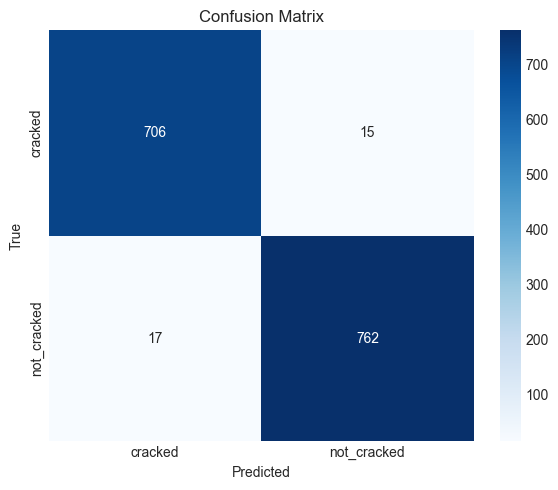

ROC-AUC: 0.9986


In [27]:
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

if len(classes) == 2:
    pos_probs = [row[1] for row in all_probs]
    auc = roc_auc_score(all_labels, pos_probs)
    print(f'ROC-AUC: {auc:.4f}')

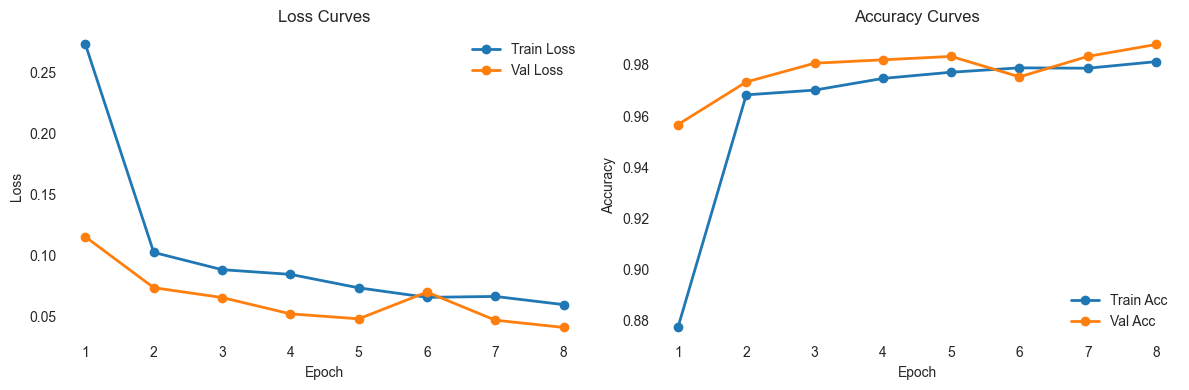

In [30]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(12, 4), facecolor='white')
plt.subplot(1, 2, 1)
plt.plot(epochs, history['train_loss'], marker='o', label='Train Loss', color='#1f77b4', linewidth=2)
plt.plot(epochs, history['val_loss'], marker='o', label='Val Loss', color='#ff7f0e', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Loss Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().set_facecolor('white')

plt.subplot(1, 2, 2)
plt.plot(epochs, history['train_acc'], marker='o', label='Train Acc', color='#1f77b4', linewidth=2)
plt.plot(epochs, history['val_acc'], marker='o', label='Val Acc', color='#ff7f0e', linewidth=2)
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Accuracy Curves')
plt.legend()
plt.grid(alpha=0.3)
plt.gca().set_facecolor('white')
plt.tight_layout()
plt.show()

## 7. Save Model and Final Summary

In [29]:
import pathlib as _pl
save_dir = _pl.Path(config.output_root) / config.experiment_name
save_dir.mkdir(parents=True, exist_ok=True)
model_path = save_dir / 'best_hybrid_quantum_cnn.pt'
torch.save(best_model.state_dict(), model_path)

print('=' * 70)
print('QUANTUM CNN CRACK CLASSIFICATION - FINAL SUMMARY')
print('=' * 70)
print(f'Dataset Root : {DATASET_ROOT}')
print(f'Classes      : {classes}')
print(f'Epochs       : {config.epochs}')
print(f'Qubits       : {config.n_qubits}  |  Q-Layers: {config.n_q_layers}')
print(f'Test Accuracy: {test_acc:.4f}')
if len(classes) == 2 and 'auc' in dir():
    print(f'ROC-AUC      : {auc:.4f}')
print(f'Training Time: {train_time/60:.2f} minutes')
print(f'Saved Model  : {model_path}')
print('=' * 70)

QUANTUM CNN CRACK CLASSIFICATION - FINAL SUMMARY
Dataset Root : /Users/anton/Documents/GitHub/Final_Year_Project/raw_classification
Classes      : ['cracked', 'not_cracked']
Epochs       : 8
Qubits       : 4  |  Q-Layers: 2
Test Accuracy: 0.9787
ROC-AUC      : 0.9986
Training Time: 18.27 minutes
Saved Model  : /Users/anton/Documents/GitHub/Final_Year_Project/runs/quantum_cnn/notebook_run/best_hybrid_quantum_cnn.pt
